In [7]:
import numpy as np
import time
import os
import random
from scipy.optimize import curve_fit
import sys
import time

import yaml
from pathlib import Path

sys.path.append('/home/rfsoc/ccatkidlib/analysis') 
from Sweep import Sweep
from Resonator import Resonator
from Timestream import Timestream
#import resonator_model_v3 as rm

from pol_analysis import *
import matplotlib.pyplot as plt
from scipy.stats import norm

%matplotlib widget


In [9]:
print(dates)

['20240827', '20240920', '20240920', '20240920', '20240920', '20240920', '20240920', '20241004', '20241004', '20241007', '20241007', '20241009', '20241016', '20241017', '20241018']


In [10]:
DEBUG = True
io_path = Path('/home/rfsoc/Andy/pol_results')/date/board/stamp
PLOT = True

dates = []
stamps = []

data_path = Path('/home/rfsoc/rfsoc_result/polarization/data/')

dates = []
stamps = []

for date in sorted(os.listdir(data_path / 'rfsoc')):
    if not date.startswith('2024'): continue
    for stamp in os.listdir(data_path / 'rfsoc' / date / 'B1D1'):
        l = len(os.listdir(data_path / 'rfsoc' / date / 'B1D1' / stamp))
        if l > 30 and l <300:
            dates.append(date)
            stamps.append(stamp)

# good data begins at 7
selection = -3

date = dates[selection]
stamp = stamps[selection]
print(date, stamp)
board = 'B1D1'

20241016 1729099397


In [3]:
# Get all the files

targs, targ_cfgs = get_targ_list(data_path, date, stamp, board)
timestreams, ts_cfgs = get_timestream_list(data_path, date, stamp, board)

with open(targ_cfgs[0]) as config:
    cfg = yaml.safe_load(config)

resonators = [Resonator(i) for i in range(cfg['rfsoc_tones']['num_tones'])]

#t1 = time.time()
for i in range(len(resonators)):
    resonators[i].add_sweep(targs[-1], i, targ_cfgs[-1])

for f, cfg in zip(timestreams, ts_cfgs):
    for i in range(len(resonators)):
        resonators[i].add_timestream(f, i,  cfg)

#print(time.time() - t1)

for res in resonators:
    res.process_timestreams()

# # Setup export folders
# if PLOT and not os.path.exists(io_path): os.mkdir(io_path)

# # Fit each detector
# res_fits = fit_resonators(targs, targ_cfgs)

# # Get cable delay terms for each resonator
# cables = cable_delays(timestreams, res_fits)


/home/rfsoc/ccatkidlib/analysis/Resonator.py:162: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(X, Y, deg)
/home/rfsoc/ccatkidlib/analysis/Resonator.py:162: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(X, Y, deg)
/home/rfsoc/ccatkidlib/analysis/Resonator.py:162: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(X, Y, deg)
/home/rfsoc/ccatkidlib/analysis/Resonator.py:162: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(X, Y, deg)
/home/rfsoc/ccatkidlib/analysis/Resonator.py:162: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(X, Y, deg)
/home/rfsoc/ccatkidlib/analysis/Resonator.py:162: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(X, Y, deg)


In [5]:
def fitfunc(x, A, C, W, p1, p2):
    # C is crosspol amplitude
    # W is wobble amplitude
    return A*(1-W*np.cos(np.pi*x/360 -p1)**2)*(np.cos(np.pi*x/180 - p2)**2 + C*np.sin(np.pi*x/180 -p2)**2)

/home/rfsoc/anaconda3/envs/rfsoc/lib/python3.9/site-packages/scipy/signal/_peak_finding.py:261: ComplexWarning: Casting complex values to real discards the imaginary part
  value = np.asarray(value, order='C', dtype=np.float64)
/home/rfsoc/ccatkidlib/scripts/polarization/analysis/pol_analysis.py:101: ComplexWarning: Casting complex values to real discards the imaginary part
  dfs[i] = highs.mean() - lows.mean()


[1.         0.01407824 0.01117361 1.76985513 0.88350442]
15.708609692683332
[1.         0.02434461 0.01102299 1.73083963 0.8724847 ]
9.04664910374659
[0.98773304 0.02919662 0.14010825 2.07628215 0.113093  ]
13.137419966250997
[0.91314212 0.30461107 0.10812505 1.91934389 2.46069901]
2.870079048849451
[1.         0.02911349 0.01279946 2.38127444 2.43018323]
9.55396524128718
[1.         0.03201963 0.01480156 2.20433656 1.63887307]
5.46194099276142


Text(0.5, 0.98, 'Polarization Data 2024/10/18')

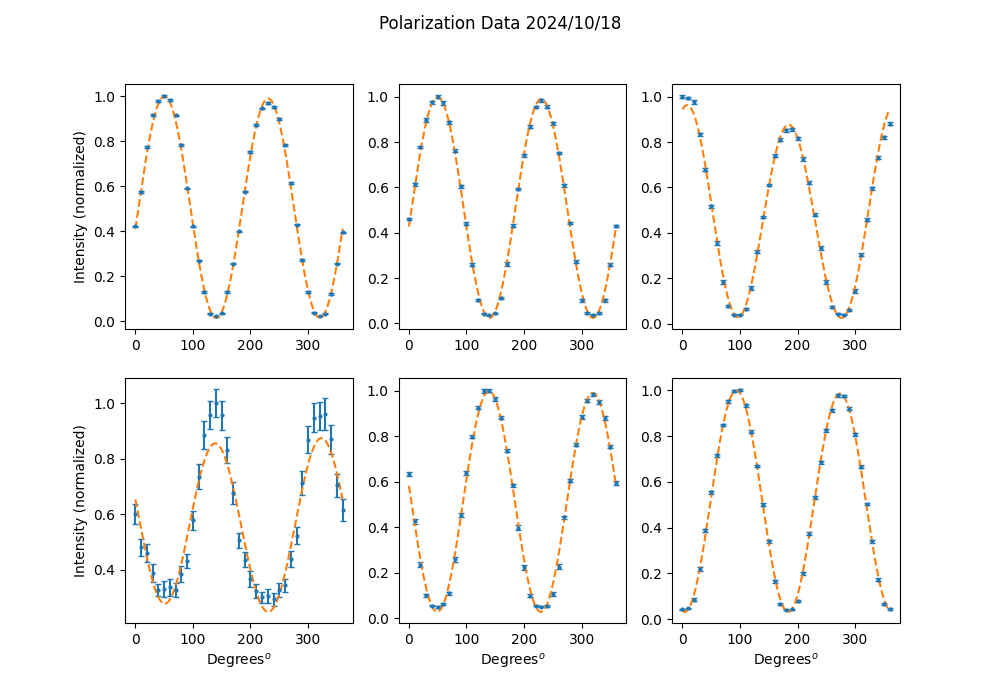

In [6]:
fig, ax = plt.subplots(2,3, figsize=(10,7))

for D, AX in enumerate(ax.flat):
    det = resonators[D]

    denoised = denoise_timestreams(det, [0,10,30,50,70], [0.1, 1,1,1,1])
    cfgs  = det.get_all_data(dtype='cfg')

    dfs, dferr = analyze_oscillations(denoised, det)

    data = []
    # Use Oscillations in Phase to get frequency Shift
    for d, u, cfg in zip(dfs, dferr, cfgs):
        data.append([cfg['pol_config']['angle'], d, u])

    data = np.array(data)
    
    angles = np.unique(data[:,0])
    intens = []
    uncs = []
    for a in angles:
        condition = np.apply_along_axis(lambda x: x[0]==a, axis=1, arr=data)
        means = data[np.argwhere(condition)][:,0,1]

        uncers = data[np.argwhere(condition)][:,0,2]
        
        inten = means.mean()
        uncer = np.sqrt(np.sum(uncers * uncers))/np.sqrt(len(uncers))
        
        intens.append(inten)
        uncs.append(uncer)
    intens = np.array(intens)
    uncs = np.array(uncs)

    uncs = uncs/intens.max()
    intens = intens/intens.max()

    AX.errorbar(angles, intens, yerr=uncs, fmt='o', markersize=2, capsize=2,)

    guess = [1, intens.min(), 0.1, 1, 1]
    bounds = [(0.5, 0, 0, -np.pi, -np.pi),(1, 0.5, 0.3, np.pi, np.pi)]
    params, covariance = curve_fit(fitfunc, angles, intens, p0=guess, bounds=bounds, sigma=uncs)
    print(params)
    print(chi_squared_reduced(intens, fitfunc(angles, *params), uncs))
    finexs = np.linspace(0, 360, 360)
    AX.plot(finexs, fitfunc(finexs, *params), '--')
    if D in [0, 3]:
        AX.set_ylabel('Intensity (normalized)')
    if D in [3,4,5]:
        AX.set_xlabel('Degrees$^o$')

fig.suptitle('Polarization Data 2024/10/18')

In [ ]:
import warnings
warnings.filterwarnings('ignore')

crosspols = []
parameters = []
for date, stamp in zip(dates[7:], stamps[7:]):
    print(date, stamp)

    targs, targ_cfgs = get_targ_list(data_path, date, stamp, board)
    timestreams, ts_cfgs = get_timestream_list(data_path, date, stamp, board)

    with open(targ_cfgs[0]) as config:
        cfg = yaml.safe_load(config)

    resonators = [Resonator(i) for i in range(cfg['rfsoc_tones']['num_tones'])]

    #t1 = time.time()
    for i in range(len(resonators)):
        resonators[i].add_sweep(targs[-1], i, targ_cfgs[-1])

    for f, cfg in zip(timestreams, ts_cfgs):
        for i in range(len(resonators)):
            resonators[i].add_timestream(f, i,  cfg)

    #print(time.time() - t1)
    try:
        for res in resonators:
            res.process_timestreams()
    except Exception:
        continue

    cp = []
    ps = []

    fig, ax = plt.subplots(2,3, figsize=(10,7))
    fig.suptitle(f'Polarization Data {date}')
    for AX, D, det in zip(ax.flat, range(len(resonators)), resonators):
        denoised = denoise_timestreams(det, [0,10,30,50,70], [0.1, 1,1,1,1])
        cfgs  = det.get_all_data(dtype='cfg')

        dfs, dferr = analyze_oscillations(denoised, det)

        data = []
        # Use Oscillations in Phase to get frequency Shift
        for d, u, cfg in zip(dfs, dferr, cfgs):
            data.append([cfg['pol_config']['angle'], d, u])

        data = np.array(data)
        
        angles = np.unique(data[:,0])
        intens = []
        uncs = []
        for a in angles:
            condition = np.apply_along_axis(lambda x: x[0]==a, axis=1, arr=data)
            means = data[np.argwhere(condition)][:,0,1]

            uncers = data[np.argwhere(condition)][:,0,2]
            
            inten = means.mean()
            uncer = np.sqrt(np.sum(uncers * uncers))/np.sqrt(len(uncers))
        
            intens.append(inten)
            uncs.append(uncer)
        intens = np.array(intens)
        uncs = np.array(uncs)

        uncs = uncs/intens.max()
        intens = intens/intens.max()

        guess = [1, 0, 0.1, 1, 1]
        bounds = [(0.5, 0, 0, -np.pi, -np.pi),(1, 0.5, 0.3, np.pi, np.pi)]

        try:
            params, covariance = curve_fit(fitfunc, angles, intens, p0=guess, bounds=bounds, sigma=uncs)
        except ValueError:
            #params = [0, intens.min()]
            raise Exception
        
        finexs = np.linspace(0, 360, 360)
        AX.errorbar(angles, intens, yerr=uncs, fmt='o', markersize=2, capsize=2,)
        AX.plot(finexs, fitfunc(finexs, *params), '--')
        if D in [0, 3]:
            AX.set_ylabel('Intensity (normalized)')
        if D in [3,4,5]:
            AX.set_xlabel('Degrees$^o$')

        cp.append(params[1])
        ps.append(params)
    
    fig.savefig(f'/home/rfsoc/Andy/pol_results/{date}_{stamp}.png')
    
    crosspols.append(cp)
    parameters.append(ps)

20241004 1728072585
20241004 1728071387
20241007 1728322158
20241007 1728274786
20241009 1728511884
20241016 1729099397
20241017 1729204589
20241018 1729268296


In [14]:
cparr = np.array(crosspols)

# 7 sets of polarization data
for i in range(6):
    cp = cparr[:,i].tolist()
    cp = cp[0:1] + cp[3:]
    cp = np.array(cp)
    print(cp.mean()*100, '+-', cp.std()*100/np.sqrt(len(cp)))
    #print(cp.std())

1.374634305897665 +- 0.10325139379736582
2.2692272203220987 +- 0.1874624435120499
3.5750391009669946 +- 1.0879892202934038
18.107222897225668 +- 3.4542656237847416
2.594054793711406 +- 0.2701024906713445
2.6718850604385604 +- 0.12079296003708938


In [19]:
print(parameters[0])

AttributeError: 'list' object has no attribute 'shape'

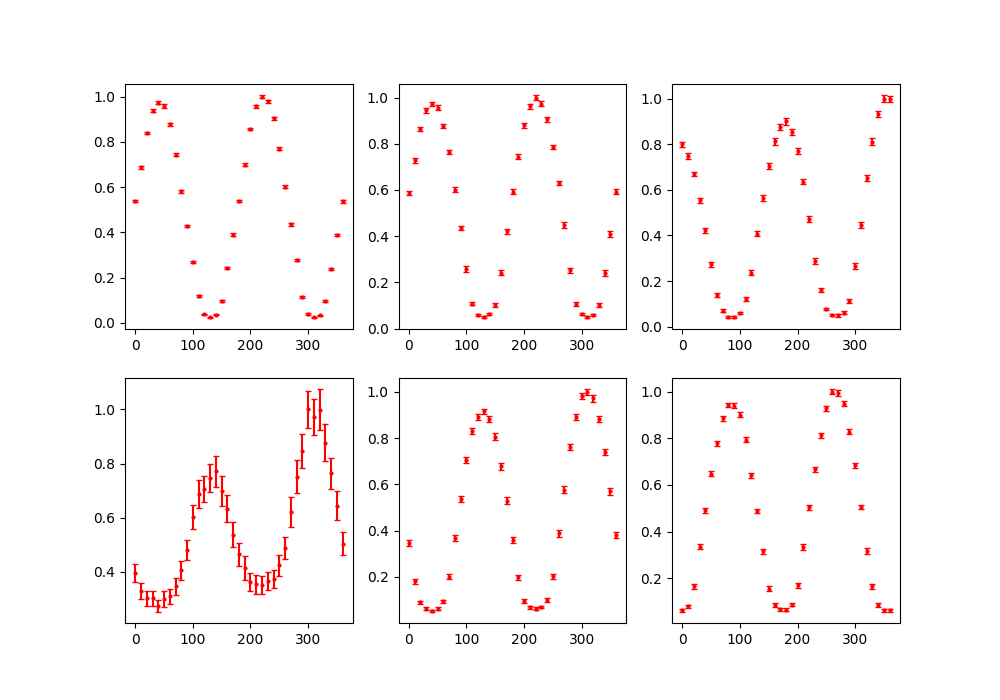

In [13]:
fig, ax = plt.subplots(2,3, figsize=(10,7))

window_freqs = [0, 10, 30, 50, 70]
window_widths = [2, 2, 2,2,2]

for d, AX in enumerate(ax.flat):
    det = resonators[d]

    denoised = denoise_timestreams(det, window_freqs, window_widths)
    cfgs  = det.get_all_data(dtype='cfg')

    dfs, dferr = analyze_oscillations(denoised, det)

    data = []
    # Use Oscillations in Phase to get frequency Shift
    for d, u, cfg in zip(dfs, dferr, cfgs):
        data.append([cfg['pol_config']['angle'], d, u])

    data = np.array(data)
    
    angles = np.unique(data[:,0])
    intens = []
    uncs = []
    for a in angles:
        condition = np.apply_along_axis(lambda x: x[0]==a, axis=1, arr=data)
        means = data[np.argwhere(condition)][:,0,1]
        uncers = data[np.argwhere(condition)][:,0,2]
        
        inten = means.mean()
        uncer = np.sqrt(np.sum(uncers * uncers))/np.sqrt(len(uncers))
        
        intens.append(inten)
        uncs.append(uncer)
    intens = np.array(intens)
    uncs = np.array(uncs)

    uncs = uncs/intens.max()
    intens = intens/intens.max()

    AX.errorbar(angles, intens, yerr=uncs, fmt='ro', markersize=2, capsize=2,)

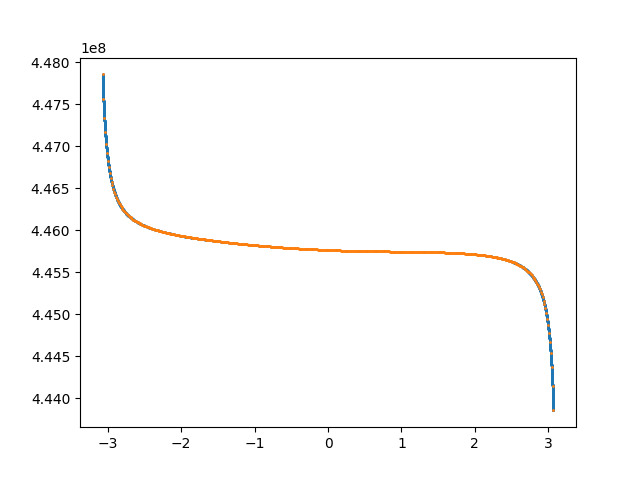

In [23]:
plt.figure()
r = resonators[0]
xs = np.linspace(r.phis.min(), r.phis.max(), 500)
plt.scatter(r.phis, r.fs, s=1)
plt.scatter(xs, r.phi_to_freq(xs), s=1)

#plt.scatter(r.phis, (r.fs - r.phi_to_freq(r.phis)) / r.fs, s=1)

11.749210284783539
198


/home/rfsoc/anaconda3/envs/rfsoc/lib/python3.9/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/rfsoc/anaconda3/envs/rfsoc/lib/python3.9/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/rfsoc/anaconda3/envs/rfsoc/lib/python3.9/site-packages/scipy/signal/_peak_finding.py:261: ComplexWarning: Casting complex values to real discards the imaginary part
  value = np.asarray(value, order='C', dtype=np.float64)


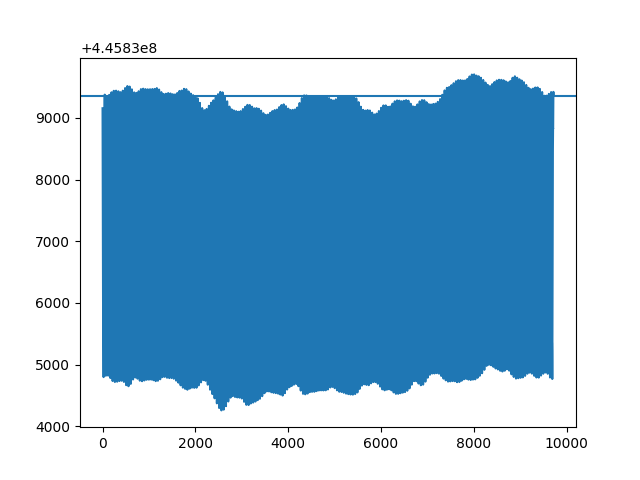

In [10]:
plt.figure()

datas = denoise_timestreams(resonators[0])
plt.plot(datas[0])
high, low = find_local_extrema(datas[0], 100)
plt.axhline(high.mean())
print(high.std() / np.sqrt(len(high)))
print(len(high))

/tmp/ipykernel_1878055/829788501.py:31: ComplexWarning: Casting complex values to real discards the imaginary part
  dfs[i] = highs.mean() - lows.mean()


24.433672844530076
97.4120884173345
0.015468735319927152
0.017347038475727307

34.16952227685179
35.2667064819623
0.028131155183152734
0.0336450699041981

79.43873438746938
201.7515749687335
0.019218389448220685
0.03205565327703217

270.6504223615437
34.29723793299453
0.1628099130134491
0.1531608809595154

79.40036562997666
169.11168027434448
0.03328057380383459
0.03558173258696831

80.21853428778248
86.66188880464651
0.023928746404542456
0.04661291925240962



Text(0.5, 0.98, 'Polarization Data 2024/10/18')

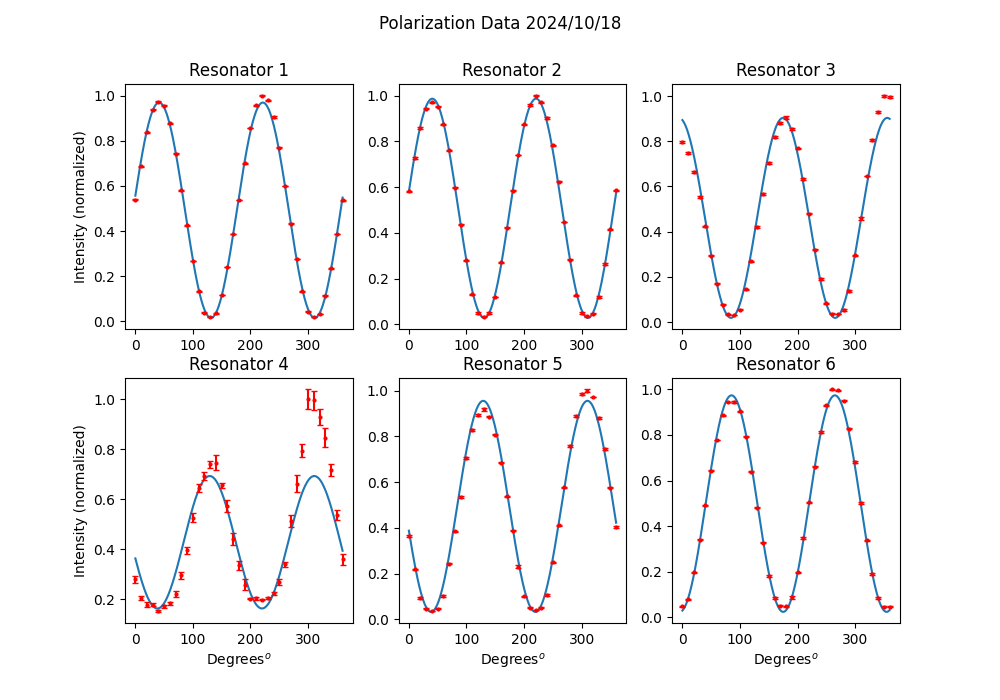

In [9]:


fig, ax = plt.subplots(2,3, figsize=(10,7))

for det, AX in enumerate(ax.flat):

    data = resonators[det].get_all_data()
    denoised = np.zeros(shape=data.shape, dtype='complex128')
    cfgs  = resonators[det].get_all_data(dtype='cfg')

    for ts, cfg, n in zip(data, cfgs, range(len(data))):
        fft = np.fft.fft(ts)
        fs = np.fft.fftfreq(len(ts), 1/(512e6/(2**20)))

        window = np.zeros(fs.shape)
        s = [0.1,1,1,1]
        freqs = [0,10,30,50]
        
        for i in range(len(freqs)):
            window += gaussian_window(fs, s[i], freqs[i])

            if freqs[i] != 0:
                window += gaussian_window(fs, s[i], -freqs[i])
        
        # apply window
        fft = fft * window
        denoised[n] = np.fft.ifft(fft).real

    dfs = np.zeros(shape=denoised.shape[0])
    funcs = np.zeros(shape=denoised.shape[0])
    for ts, i in zip(denoised, range(len(denoised))):
        highs, lows = find_local_extrema(ts, ts.std()/3)
        dfs[i] = highs.mean() - lows.mean()
        funcs[i] = (highs.std() + lows.std()) / np.sqrt(len(highs))
        #dfs[i] = 2*ts.std()

    print(funcs.mean())
    data = []
    data2 = []
    # Use Oscillations in Phase to get frequency Shift
    for d, cfg in zip(dfs, cfgs):
        data.append((cfg['pol_config']['angle'], d))
    
    for d, cfg in zip(funcs, cfgs):
        data2.append((cfg['pol_config']['angle'], d))

    angles, mean, unc = sort_data(data)
    angles2, mean2, unc2 = sort_data(data) 
    

    unc = unc / mean.max()
    mean = mean / mean.max()

    
    

    def sinfunc(x, a, w, p, d):
        return a*np.sin(w*x-p) + d
    
    def asymsin(x, a, b, w1, p1, p2):
        return a*np.sin(w1*x-p1)*np.sin(w1*x-p2) + b*np.sin(w1/2 *x-p1)*np.sin(w1/2 *x-p2)

    # guess = [0.9, 0.05, np.pi/180, 0, 0.2]
    # bounds = [(0, 0, np.pi/200, -np.pi, -np.pi),(1.2, 1.2, np.pi/100, np.pi, np.pi)]
    # params, covariance = curve_fit(asymsin, angles, mean, p0=guess, bounds=bounds, sigma=unc)

    guess = [(mean.max() - mean.min()), 2*np.pi/180, 0, mean.mean()]
    bounds = [(0, 2*np.pi/190, -100, -np.inf),(1.6*(mean.max() - mean.min()), 2*np.pi/170, 100, np.inf)]
    params, covariance = curve_fit(sinfunc, angles, mean, p0=guess, bounds=bounds, sigma=unc)

    xs = np.linspace(0,360,360)
    AX.plot(xs, sinfunc(xs, *params)) 
    AX.errorbar(x=angles, y=mean, yerr=unc, fmt='ro', markersize=2, capsize=2, label='data')

    if det in [0, 3]:
        AX.set_ylabel('Intensity (normalized)')
    if det in [3,4,5]:
        AX.set_xlabel('Degrees$^o$')
    
    AX.set_title(f'Resonator {det+1}')

    print(chi_squared_reduced(mean,sinfunc(angles, *params), unc, len(params)))
    print(sinfunc(xs, *params).min())
    print(mean.min())
    print()
    
plt.suptitle('Polarization Data 2024/10/18')



In [4]:
det = 4

data = resonators[det].get_all_data(dtype='phi')
denoised = np.zeros(shape=data.shape, dtype='complex128')
cfgs  = resonators[det].get_all_data(dtype='cfg')

for ts, cfg, n in zip(data, cfgs, range(len(data))):
    fft = np.fft.fft(ts)
    fs = np.fft.fftfreq(len(ts), 1/(512e6/(2**20)))

    window = np.zeros(fs.shape)
    s = [0.05,0.1,0.1,0.1]
    freqs = [0,10,30,50]
    
    for i in range(len(freqs)):
        window += gaussian_window(fs, s[i], freqs[i])

        if freqs[i] != 0:
            window += gaussian_window(fs, s[i], -freqs[i])
    
    # apply window
    fft = fft * window
    denoised[n] = np.fft.ifft(fft).real

dps = np.zeros(shape=denoised.shape[0])
for ts, i in zip(denoised, range(len(denoised))):
    p1 = ts.mean()+ts.std()
    p2 = ts.mean()-ts.std()
    dp = np.abs(resonators[det].phi_to_freq(p1) - resonators[det].phi_to_freq(p2))
    dps[i] = dp

data = []
# Use Oscillations in Phase to get frequency Shift
for d, cfg in zip(dfs, cfgs):
    data.append((cfg['pol_config']['angle'], d))

print(dfs[0:5].std())
angles, mean, unc = sort_data(data) 

unc = unc / mean.max()
mean = mean / mean.max()


plt.figure()
plt.errorbar(x=angles, y=mean, yerr=unc, fmt='ro', markersize=2, capsize=2, label='data')




NameError: name 'dfs' is not defined

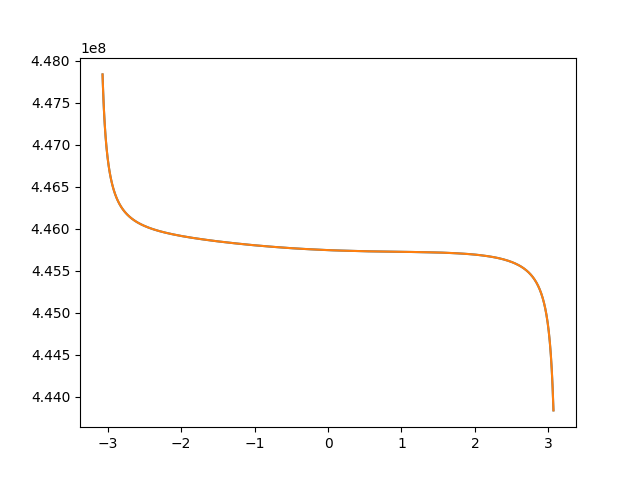

In [6]:
plt.figure()
plt.plot(resonators[det].phis, resonators[det].phi_to_freq(resonators[det].phis))
plt.plot(resonators[det].phis, resonators[det].fs)

/home/rfsoc/anaconda3/envs/rfsoc/lib/python3.9/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/rfsoc/anaconda3/envs/rfsoc/lib/python3.9/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


185


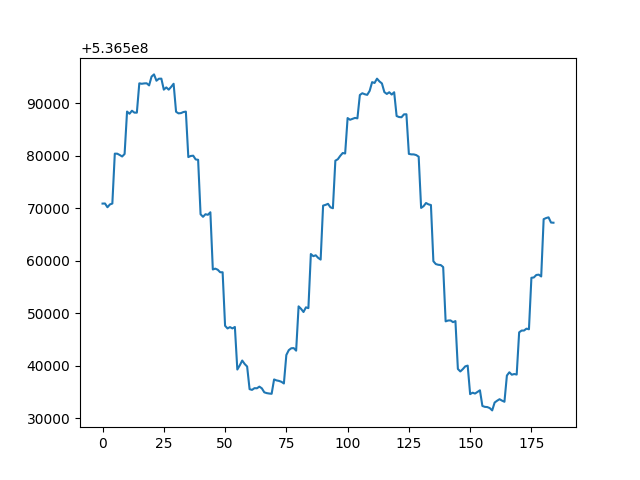

In [8]:
det = 1
data = resonators[det].get_all_data()
print(len(resonators[det].streams))
means = [i.mean() for i in data]
plt.figure()
plt.plot(means)

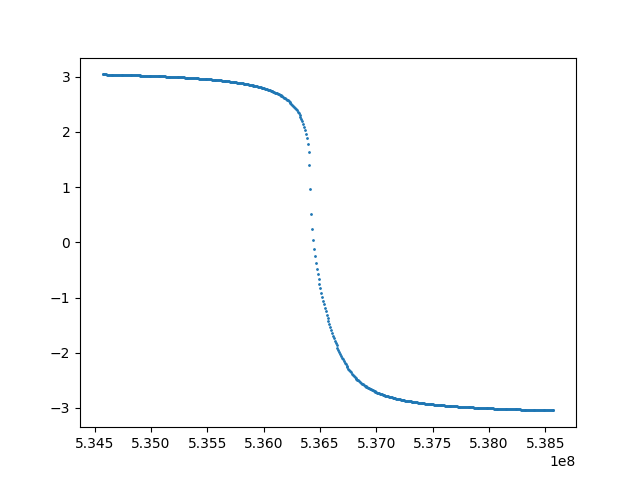

In [6]:
plt.figure()
plt.scatter(resonators[1].fs, resonators[1].phis, s=1)


100416.73612266779


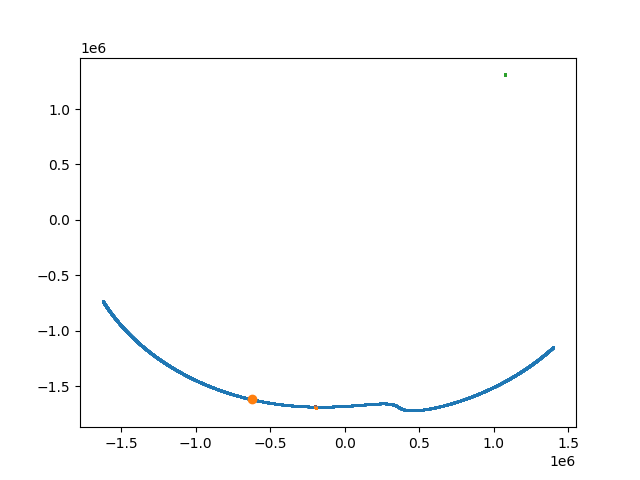

In [38]:
%matplotlib widget

def load_ts(num, det):
    ts1 = np.load(timestreams[num])[det]
    with open(ts_cfgs[num]) as config:
        cfg1 = yaml.safe_load(config)
    
    return ts1, cfg1

det = 1
fit = res_fits[det]
ts1, cfg1 = load_ts(1, det)

with open(ts_cfgs[1]) as config:
    cfg1 = yaml.safe_load(config)
with open(ts_cfgs[2]) as config:
    cfg2 = yaml.safe_load(config)

plt.figure()

plt.scatter(fit.s21z.real, fit.s21z.imag, s=1)
i1 = np.argmin(np.abs(cfg1['rfsoc_tones']['tone_freqs'][det] - fit.fs))
index = np.argmin(np.abs(ts1.mean() - fit.s21z))
print(fit.fs[i1] - fit.fs[index])
#ts1 = ts1 / fit.cable[i1]
plt.scatter(fit.s21z.real[i1], fit.s21z.imag[i1],)

for i in range(len(timestreams[:20])):
    ts1, cfg1 = load_ts(i, det)
    #index = np.argmin(np.abs(ts1.mean() - fit.s21z))
    ts1 = ts1 #/ fit.cable[index]
    plt.scatter(ts1.real, ts1.imag, s=1)



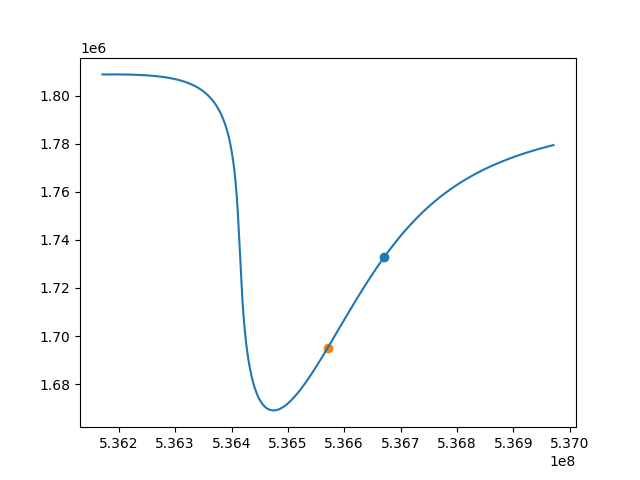

In [39]:
plt.figure()
plt.plot(fit.fs, np.abs(fit.s21z))
plt.scatter(fit.fs[i1], np.abs(fit.s21z[i1]))
plt.scatter(fit.fs[index], np.abs(fit.s21z[index]))

In [7]:
ANGLES, MEAN, UNC = analyze_polarization()

Using nonlinear model...
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear model...
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear model...
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear model...
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear model...
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear model...
Using nonlinear resonator model
Using nonlinear resonator model


0.056074766355140186

0.09392265192964966

0.10211267605522972

0.2894736842096751

0.1101449275350077

0.11020881670421157



Text(0.5, 0.98, 'Polarization Data 2024/10/16 Using Gaussian Windows')

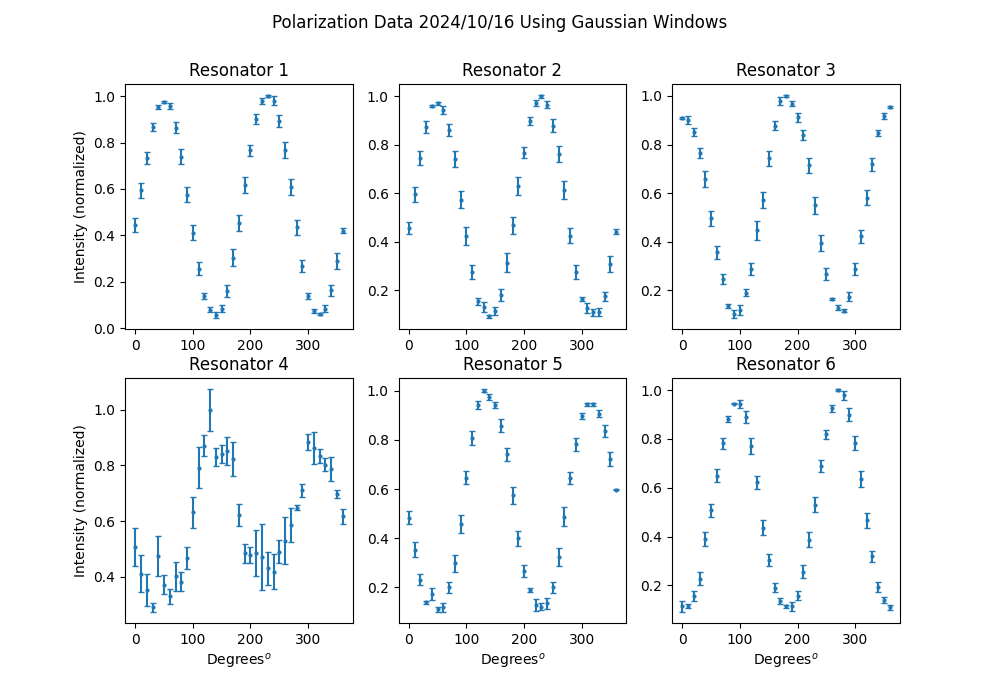

In [8]:
%matplotlib widget
fig, ax = plt.subplots(2,3, figsize=(10,7))

for det, AX in enumerate(ax.flat):
    Y = MEAN[det, :]
    unc = UNC[det]
    unc = unc / Y.max()
    for i in range(len(unc)):
        if unc[i] == 0: unc[i] = unc.std()
    Y = Y / Y.max()
    AX.errorbar(ANGLES[0], Y, yerr=unc, fmt='o',markersize=2, capsize=2,)
    
#     fit_p = fit_sin(ANGLES[0], Y, unc=unc)
#     fit = sinfunc(ANGLES[0], fit_p[0],fit_p[1], fit_p[2], fit_p[3])
#     AX.plot(ANGLES[0], fit, label='fit')
    
    print(min(Y))
#     print(chi_squared_reduced(fit, Y, unc))
    print()
    if det in [0, 3]:
        AX.set_ylabel('Intensity (normalized)')
    if det in [3,4,5]:
        AX.set_xlabel('Degrees$^o$')
    
    AX.set_title(f'Resonator {det+1}')
plt.suptitle('Polarization Data 2024/10/16 Using Gaussian Windows')



Using nonlinear model...
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear model...
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear model...
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear model...
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear model...
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear model...
Using nonlinear resonator model
Using nonlinear resonator model
0.04464285714267899

0.07514450866932551

0.09374999999860324

0.2583333333351957

0.07819905212980507

0.11363636363425285



Text(0.5, 0.98, 'Polarization Data 2024/10/16 Using Clip Windows')

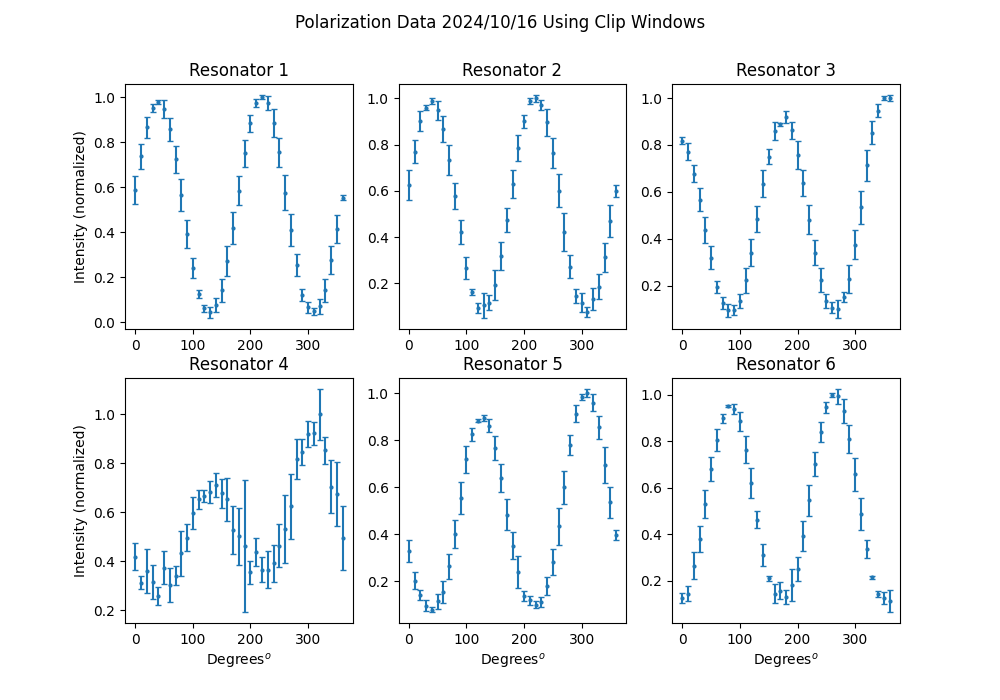

In [7]:
ANGLES, MEAN, UNC = analyze_polarization()

%matplotlib widget
fig, ax = plt.subplots(2,3, figsize=(10,7))

for det, AX in enumerate(ax.flat):
    Y = MEAN[det, :]
    unc = UNC[det]
    unc = unc / Y.max()
    for i in range(len(unc)):
        if unc[i] == 0: unc[i] = unc.std()
    Y = Y / Y.max()
    AX.errorbar(ANGLES[0], Y, yerr=unc, fmt='o',markersize=2, capsize=2,)
    
    # try:
    # fit_p = fit_sin(ANGLES[0], Y, unc=unc)
    # fit = sinfunc(ANGLES[0], fit_p[0],fit_p[1], fit_p[2], fit_p[3])
    # AX.plot(ANGLES[0], fit, label='fit')
    # except Exception:
    
    print(min(Y))
#     print(chi_squared_reduced(fit, Y, unc))
    print()
    if det in [0, 3]:
        AX.set_ylabel('Intensity (normalized)')
    if det in [3,4,5]:
        AX.set_xlabel('Degrees$^o$')
    
    AX.set_title(f'Resonator {det+1}')
plt.suptitle('Polarization Data 2024/10/16 Using Clip Windows')



140.0
0.0019173564897553056
0.0010624503025314356


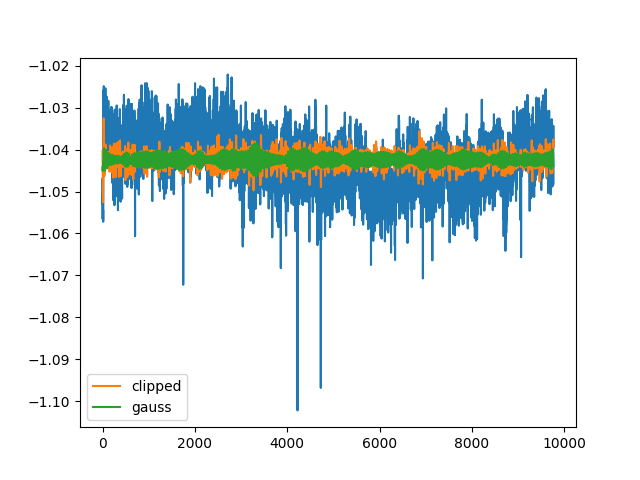

In [6]:
%matplotlib widget

wt = 'gaussian'
det=0
tsnum = 70

ts = np.load(timestreams[tsnum])[det]
fit = res_fits[det]
cab = cables[det]

with open(ts_cfgs[tsnum]) as config:
    cfg = yaml.safe_load(config)

print(cfg['pol_config']['angle'])


# Normalize to circle
ts_norm = ts / cab

# Derotate and Center
ts_norm = derotate_center(ts_norm, res_fits[det])

# Turn into Phase
phi = np.arctan2(ts_norm.imag, ts_norm.real)
fft = np.fft.fft(phi)
fs = np.fft.fftfreq(len(phi), 1/(512e6/(2**20)))

# Filter out noise
fftclip = fft*1

for i in range(len(fft)):
    if np.abs(fs[i]) > 0 and np.abs(fs[i]) < 9.5:
        fftclip[i] = 0
    if np.abs(fs[i]) > 30:
        fftclip[i] = 0


# setup window
window = np.zeros(fs.shape)
s = [0.01, 1, 0.5, 0.5, 0.1, 0.1]
freqs = [0,10,30,50,70,90]

for i in range(len(freqs)):
    window += gaussian_window(fs, s[i], freqs[i])

    if i != 0:
        window += gaussian_window(fs, s[i], -freqs[i])

# apply window
nfft = fft * window

cleaned1 = np.fft.ifft(fftclip).real
cleaned2 = np.fft.ifft(nfft).real

plt.figure()
plt.plot(phi)
plt.plot(cleaned1, label='clipped')
plt.plot(cleaned2, label='gauss')
plt.legend()
print(cleaned1.std())
print(cleaned2.std())


/tmp/ipykernel_1026480/327839024.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot(fs, np.log(window))


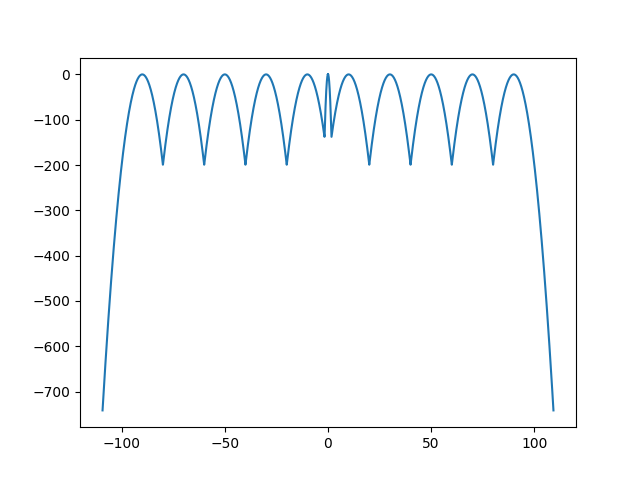

In [21]:
plt.figure()
plt.plot(fs, np.log(window))

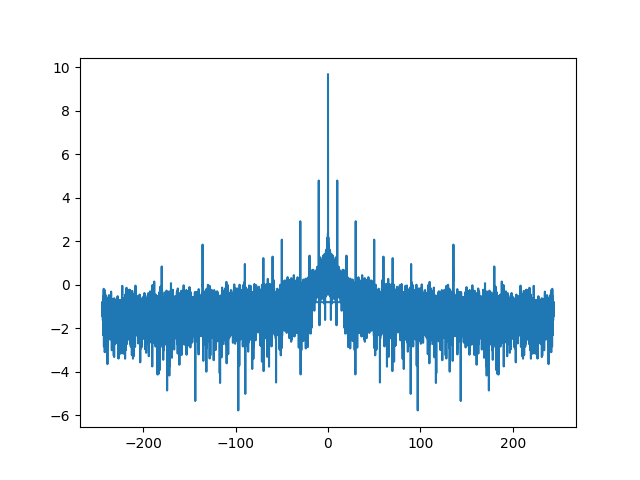

In [8]:
plt.figure()
plt.plot(fs, np.log(np.abs(fft)))

<IPython.core.display.Javascript object>


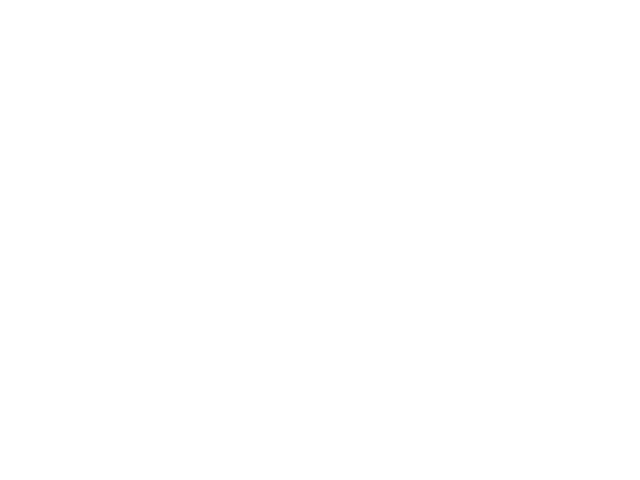

TypeError: expected str, bytes or os.PathLike object, not ndarray

In [42]:
h = []
l = []
plt.figure()
for ts in timestreams[:1]:
    d = np.load(ts)
    d = d[det][20:] / fit.cable[n]
    #d = derotate_center(d, fit)
    #plt.scatter(d.real, d.imag, s=2)
    p = np.arctan2(d.imag,d.real)
    H, L = analyze_oscillations(p, ts_cfgs[0], res_fits)
    h.append(H)
    l.append(L)
plt.plot(np.array(h) - np.array(l))

#v = np.array(v)
#plt.plot(v)

<IPython.core.display.Javascript object>


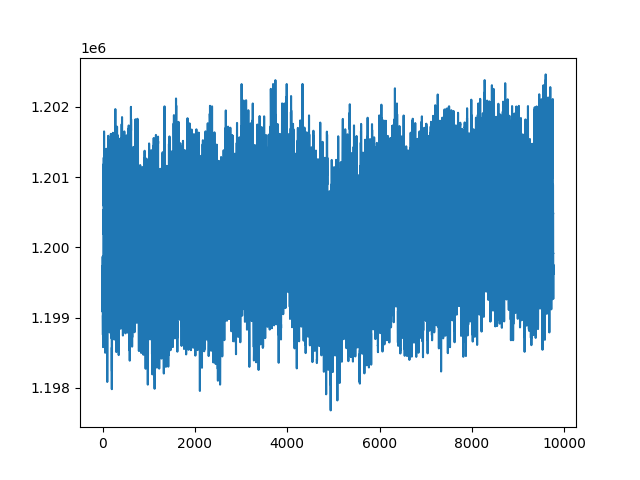

In [34]:
plt.figure()
plt.plot(np.load(timestreams[1])[0])

<IPython.core.display.Javascript object>


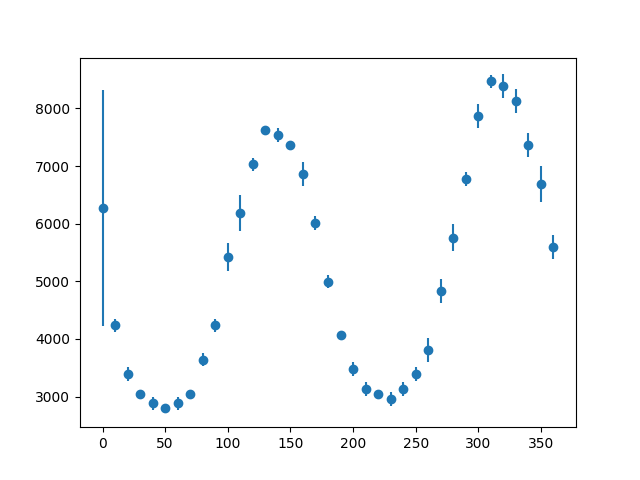

<ErrorbarContainer object of 3 artists>

In [47]:
plt.figure()
plt.errorbar(Angles, Data, yerr=unc, fmt='o')

<IPython.core.display.Javascript object>


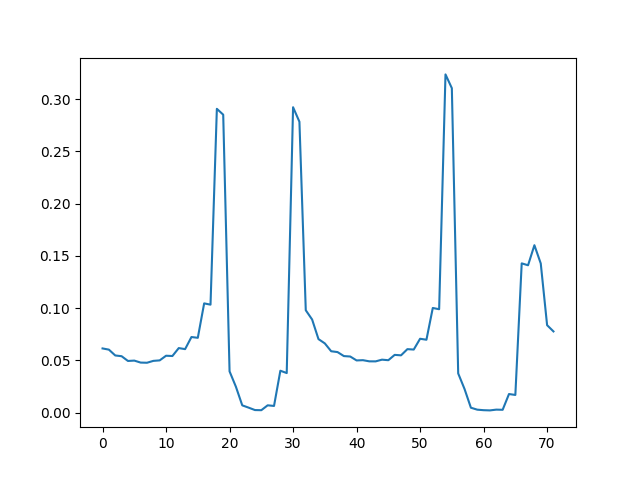

(72, 1)

In [6]:
plt.figure()
det = 0
h = osc_values[1:,det,0]
l=osc_values[1:,det,1]
plt.plot(h-l)
np.diff(osc_values[1:,3]).shape

<IPython.core.display.Javascript object>


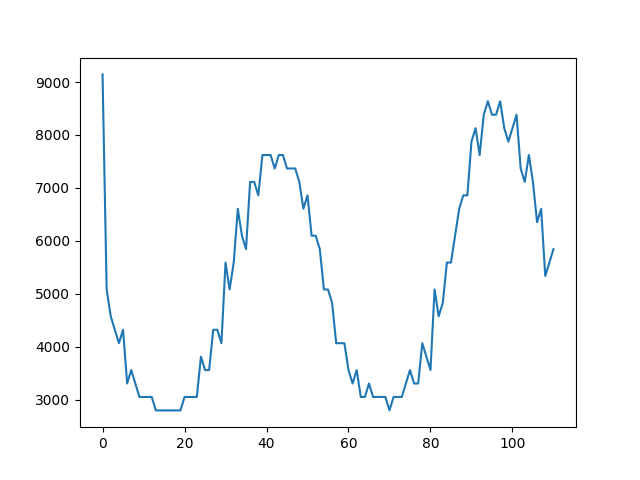

In [39]:
plt.figure()
plt.plot(dfs)

In [72]:
analyze_oscillations(timestreams[1], ts_cfgs[0], res_fits)

Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model


[(-1.3739891258307269, -1.3974305634584276),
 (-1.4035346042937424, -1.4231118239439609),
 (-0.9030248185940242, -0.9621332004958512),
 (-1.4565856928656016, -1.4798790717786494),
 (-0.9597860723833573, -0.9831355061531284),
 (-0.729973098372554, -0.7357713665401334)]

In [7]:
%matplotlib inline
det = 3

ts = np.load(timestreams[100])[det]

s21norm, s21fit, cable = res_fits[det].normalize_sweep()
fit = res_fits[det]

n1 = np.argmin(abs(res_fits[det].s21z-ts.mean()))
if abs(res_fits[det].s21z[n1+1]-ts.mean()) > abs(res_fits[det].s21z[n1-1]-ts.mean()):
    n2 = n1-1
else:
    n2 = n1+1
    
cab = (cable[n1]+cable[n2])/2
ts_norm = ts / cab



IndexError: list index out of range

In [8]:
plt.figure()

ts_rot = derotate_center(ts_norm, fit)
s21c = derotate_center(s21fit, fit)
s21c = s21c

plt.scatter(s21c.real, s21c.imag, s=2)
plt.scatter(ts_rot.real, ts_rot.imag, s=1)
plt.grid()

NameError: name 'ts_norm' is not defined

<Figure size 640x480 with 0 Axes>

<IPython.core.display.Javascript object>


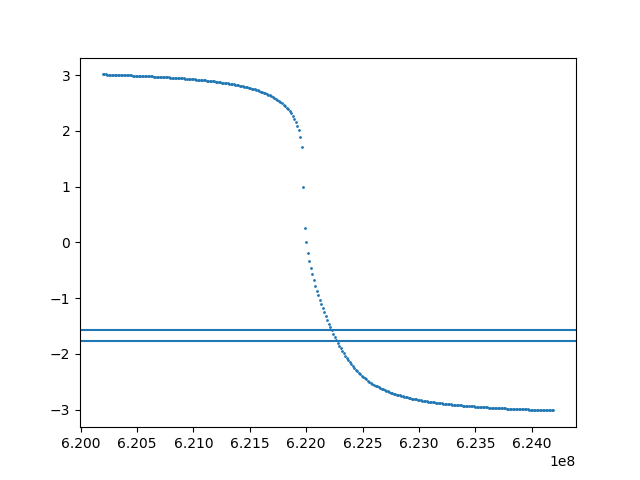

In [34]:
plt.figure()
phis = np.arctan2(s21c.imag, s21c.real)
plt.scatter(fit.fs, phis, s=1)
plt.axhline(np.arctan2(ts_rot.imag, ts_rot.real).max())
plt.axhline(np.arctan2(ts_rot.imag, ts_rot.real).min())

Using nonlinear resonator model


<IPython.core.display.Javascript object>


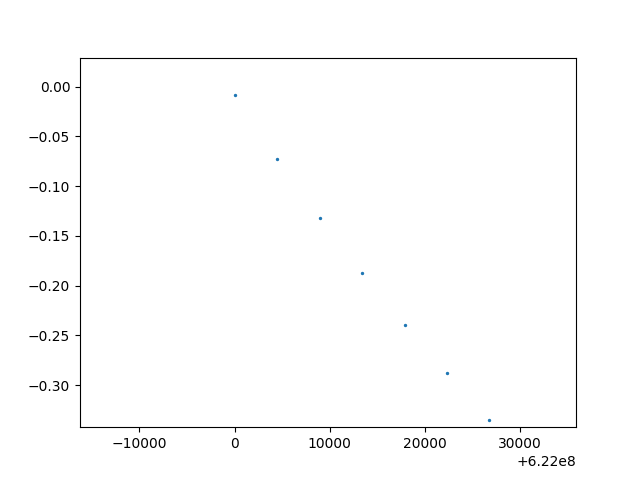

NameError: name 'params' is not defined

In [35]:

finefs = np.linspace(fit.fs.min(), fit.fs.max(), 3*len(fit.fs)) 
fine_s21 = rm.fine_s21_model(finefs, fit.fitparams.params, asymm=True)
cab = rm.fine_s21_model(finefs, fit.fitparams.params, cable=True)
fine_s21 = fine_s21 / cab

s21c = derotate_center(fine_s21, fit)
phis = np.arctan2(s21c.imag, s21c.real)
plt.figure()
plt.axhline(np.arctan2(ts_rot.imag, ts_rot.real).max())
plt.axhline(np.arctan2(ts_rot.imag, ts_rot.real).min())
plt.scatter(finefs, phis, s=2)
print(params)


In [122]:
def get_frequency_shift(phi1, phi2, fit, res=15):
    # Calculates abs frequency shift of resonator based on two phases
    # Fits phase curve using arctan
    # Returns frequency shift in Hz
    
    D = np.abs(fit.fs.min() - fit.fs.max())
    
    finefs = np.linspace(fit.fs.mean()-D/7, fit.fs.mean()+D/7, res*len(fit.fs)) 
    fine_s21 = rm.fine_s21_model(finefs, fit.fitparams.params, asymm=True)
    cab = rm.fine_s21_model(finefs, fit.fitparams.params, cable=True)
    fine_s21 = fine_s21 / cab

    s21c = derotate_center(fine_s21, fit)
    phis = np.arctan2(s21c.imag, s21c.real)
    
    n1 = np.argmin(np.abs(phis-phi1))
    n2 = np.argmin(np.abs(phis-phi2))
    
    df = np.abs(finefs[n1] - finefs[n2])
    
    return df

    

''

In [111]:
get_frequency_shift(np.arctan2(ts_rot.imag, ts_rot.real).max(),np.arctan2(ts_rot.imag, ts_rot.real).min(), fit)

Using nonlinear resonator model


16005.335111737251

In [123]:
dfs = []
for point in osc_values[:,det]:
    df = get_frequency_shift(point[0], point[1],res_fits[det], )
    dfs.append(df)

Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using nonlinear resonator model
Using no

<IPython.core.display.Javascript object>


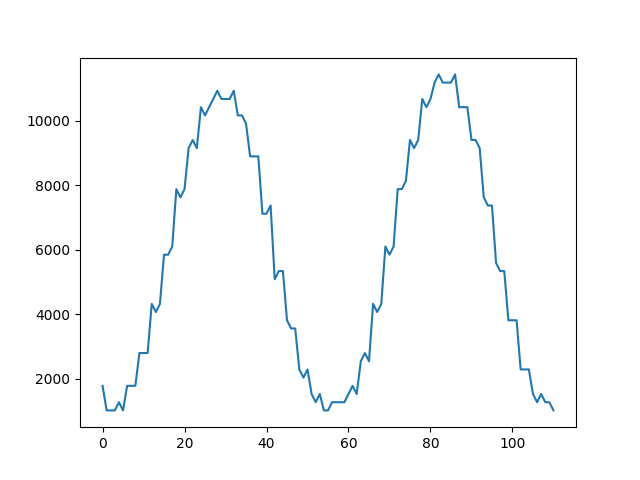

In [116]:
plt.figure()
plt.plot(dfs)

<IPython.core.display.Javascript object>


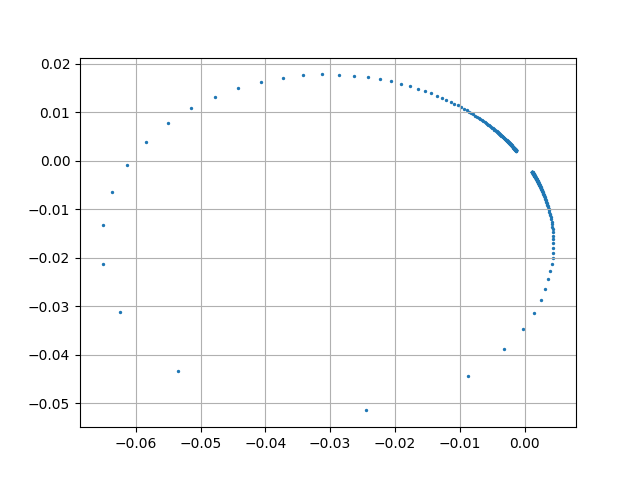

In [228]:
plt.figure()

plt.scatter(s21fit.real -1, s21fit.imag, s=2)
#plt.scatter(ts_norm.real, ts_norm.imag, s=1)
plt.grid()

<IPython.core.display.Javascript object>


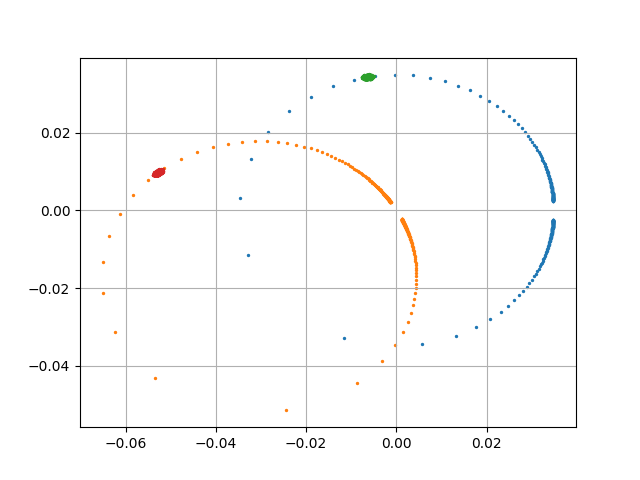

In [244]:
Qe = res_fits[det].fitparams.params['Q_e_real']+1j*res_fits[det].fitparams.params['Q_e_imag']
s = res_fits[det].fitparams.params['Q']/np.abs(Qe)
r = np.arctan2(Qe.imag, Qe.real)
plt.figure()

newcab = cable

s21fitrot = np.exp(1j*r)*(s21fit - 1)+s/2.0

normconst = np.exp(1j*r)#(s21fitrot/s21fit)
ts_rot = (ts_norm-1) * normconst + s/2.0

plt.scatter(s21fitrot.real,s21fitrot.imag, s=2)
plt.scatter(s21fit.real-1, s21fit.imag, s=2)
plt.scatter(ts_rot.real, ts_rot.imag, s=2)
plt.scatter(ts_norm.real-1, ts_norm.imag, s=2)

plt.grid()

    

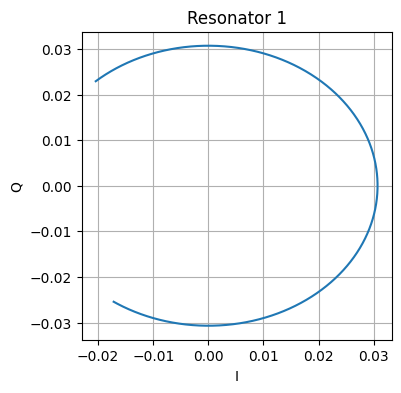

In [16]:
plt.figure(figsize=(4, 4))
det = 5
#plt.plot(res_fits[det].s21norm.real, res_fits[det].s21norm.imag, label='resonator')
s21rot = derotate_center(res_fits[det].s21norm, res_fits[det])
plt.title('Resonator 1')
plt.xlabel('I')
plt.ylabel('Q')
plt.plot(s21rot.real, s21rot.imag, label='resonator')
#plt.xticks(np.arange(-0.2, 1.2, 0.1))
plt.grid()

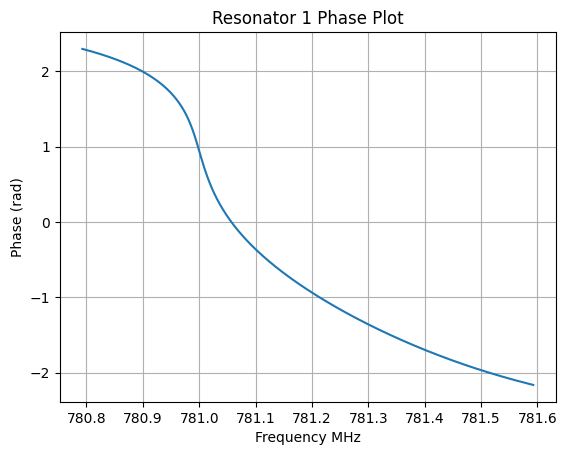

In [17]:
phis = np.arctan2(s21rot.imag, s21rot.real)
plt.plot(res_fits[det].fs / 1e6, phis)
plt.title('Resonator 1 Phase Plot')
plt.xlabel('Frequency MHz')
plt.ylabel('Phase (rad)')
plt.grid()

In [7]:
#find cable term once
ts = np.load(timestreams[0])[det][2000:5000]
fit = res_fits[det]

# Find closest cable term
n1 = np.argmin(abs(res_fits[det].s21z-ts.mean()))
if abs(res_fits[det].s21z[n1+1]-ts.mean()) > abs(res_fits[det].s21z[n1-1]-ts.mean()):
    n2 = n1-1
else:
    n2 = n1+1
if DEBUG:
    cab = (fit.cable[n1]+fit.cable[n2])/2
else:
    cab = (cable[n1]+cable[n2])/2



ts = np.load(timestreams[60])[det][2000:5000]
fit = res_fits[det]

with open(ts_cfgs[60]) as config:
    cfg = yaml.safe_load(config)

print(cfg['pol_config']['angle'])

if not DEBUG: s21norm, s21fit, cable = fit.normalize_sweep()

# Find closest cable term
n1 = np.argmin(abs(res_fits[det].s21z-ts.mean()))
if abs(res_fits[det].s21z[n1+1]-ts.mean()) > abs(res_fits[det].s21z[n1-1]-ts.mean()):
    n2 = n1-1
else:
    n2 = n1+1

# if DEBUG:
#     cab = (fit.cable[n1]+fit.cable[n2])/2
# else:
#     cab = (cable[n1]+cable[n2])/2

#cab = fit.cable[n1]
ts_norm = ts / cab

# Derotate and Center
ts_norm = derotate_center(ts_norm, res_fits[det])

# Turn into Phase
phi = np.arctan2(ts_norm.imag, ts_norm.real)
fft = np.fft.fft(phi)
fs = np.fft.fftfreq(len(phi), 1/(512e6/(2**20)))

# Filter out noise
for i in range(len(fft)):
    if np.abs(fs[i]) > 0 and np.abs(fs[i]) < 9.5:
        fft[i] = 0
    if np.abs(fs[i]) > 30:
        fft[i] = 0

cleaned = np.fft.ifft(fft).real
top = cleaned.mean()+cleaned.std()
bot = cleaned.mean()-cleaned.std()

300.0


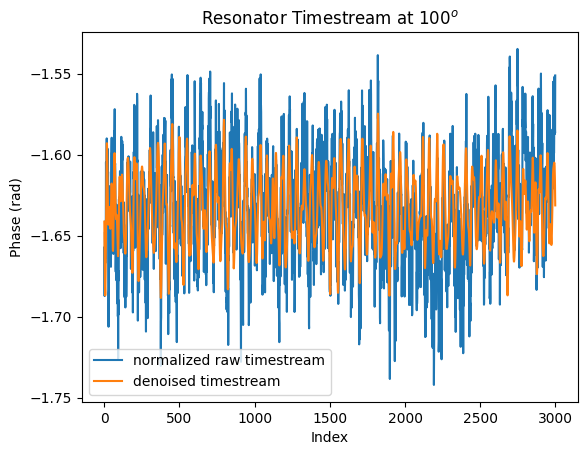

In [8]:
plt.title('Resonator Timestream at $100^o$')
plt.plot(phi, label='normalized raw timestream')
plt.plot(cleaned, label='denoised timestream')
plt.xlabel('Index')
plt.ylabel('Phase (rad)')
plt.legend()

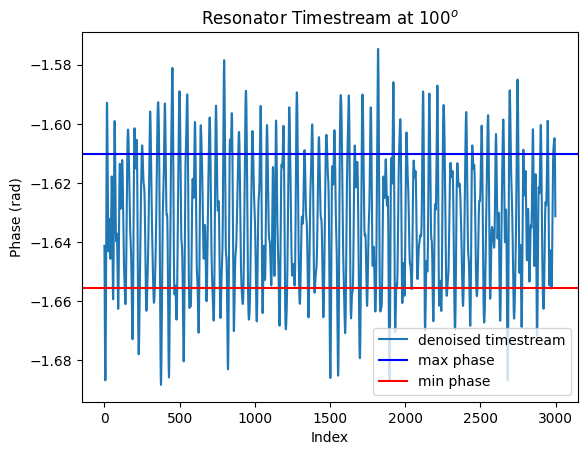

In [9]:
plt.title('Resonator Timestream at $100^o$')

plt.plot(cleaned, label='denoised timestream')
plt.axhline(top, label='max phase', color='b')
plt.axhline(bot, label='min phase', color='r')
plt.xlabel('Index')
plt.ylabel('Phase (rad)')

plt.legend()

25.239577823219033


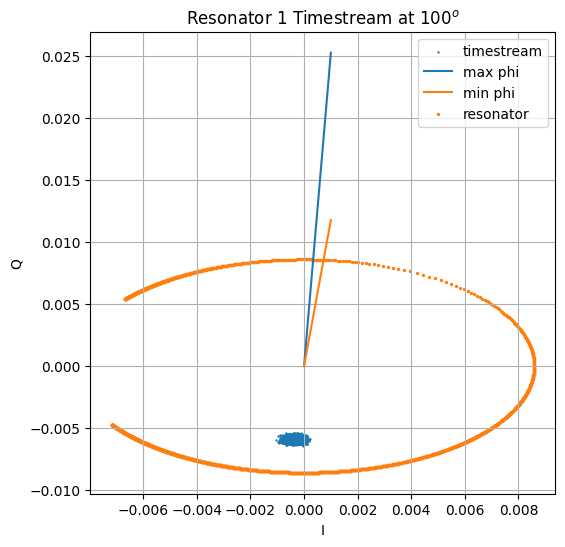

In [10]:
plt.figure(figsize=(6,6))

print(np.tan(top))
plt.scatter(ts_norm.real, ts_norm.imag, s=0.5, label='timestream')
x1 = np.array([0,0.001])
x2 = np.array([0,0.001])
l1 = np.tan(top)*x1
l2 = np.tan(bot)*x2
plt.plot(x1, l1, label='max phi')
plt.plot(x2, l2, label='min phi')
plt.scatter(s21rot.real, s21rot.imag, s=2, label='resonator')
plt.grid()
plt.ylabel('Q')
plt.xlabel('I')
plt.title('Resonator 1 Timestream at $100^o$')
plt.legend()
#plt.xlim(0)
#plt.ylim(0)

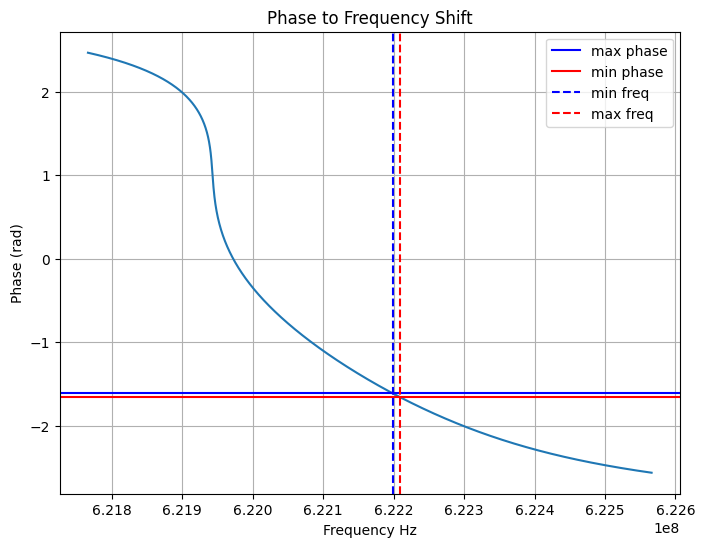

In [11]:
plt.figure(figsize=(8,6))
phis = np.arctan2(s21rot.imag, s21rot.real)
plt.plot(res_fits[det].fs / 1, phis)
plt.axhline(top, label='max phase', color='b')
plt.axhline(bot, label='min phase', color='r')

n1 = np.argmin(np.abs(phis-top))
n2 = np.argmin(np.abs(phis-bot))
plt.axvline(res_fits[det].fs[n1] / 1, label='min freq', color='b', ls='--')
plt.axvline(res_fits[det].fs[n2] / 1, label='max freq', color='r', ls='--')

plt.title('Phase to Frequency Shift')
plt.xlabel('Frequency Hz')
plt.ylabel('Phase (rad)')
plt.legend()
plt.grid()

#plt.xlim((res_fits[det].fs[n2] -10000) / 1 , (res_fits[det].fs[n1] +10000)/ 1)
#plt.ylim(0.5, 1.5)
#plt.xticks(np.arange(res_fits[det].fs[n2]/1e6, res_fits[det].fs[n1]/1e6, 0.1))

<IPython.core.display.Javascript object>


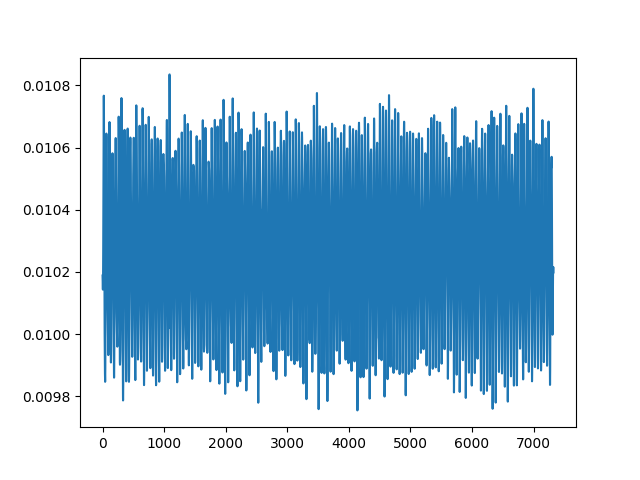

In [147]:
plt.figure()
cleaned = np.fft.ifft(fft).real
plt.plot(cleaned)

<IPython.core.display.Javascript object>


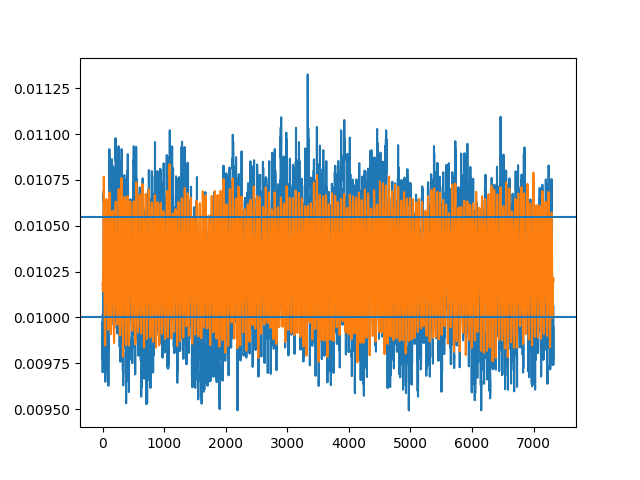

In [148]:
plt.figure()

top = cleaned.mean()+cleaned.std()
bot = cleaned.mean()-cleaned.std()

#plt.plot(np.abs(cleaned))
plt.plot(phi)
plt.plot(cleaned)
plt.axhline(top)
plt.axhline(bot)



<IPython.core.display.Javascript object>


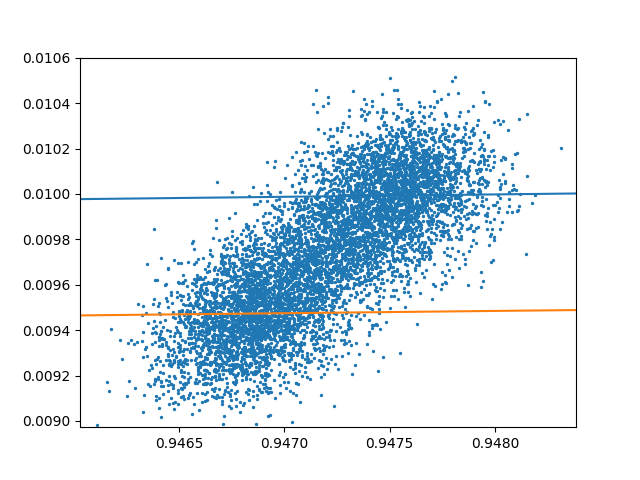

0.010546329842925846


(0.92, 1.01)

In [149]:
plt.figure()

print(np.tan(top))
plt.scatter(ts_norm.real, ts_norm.imag, s=2)
x = [0,1]
l1 = [0, np.tan(top)]
l2 = [0, np.tan(bot)]
plt.plot(x, l1)
plt.plot(x, l2)
plt.scatter(s21fit.real, s21fit.imag, s=2)
plt.xlim(0.92,1.01)


In [158]:
def analyze_oscillations(timestream, cfg, res_fits):
    # Analyzes oscillations in timestream at 10Hz
    # Does noise reduction by clipping frequencies in fourier space
    
    ret = []
    
    for det in range(len(res_fits)):
        ts = np.load(timestream)[det]
        s21norm, s21fit, cable = res_fits[det].normalize_sweep()
        
        # Find closest cable term
        n1 = np.argmin(abs(res_fits[det].s21z-ts.mean()))
        if abs(res_fits[det].s21z[n1+1]-ts.mean()) > abs(res_fits[det].s21z[n1-1]-ts.mean()):
            n2 = n1-1
        else:
            n2 = n1+1
        
        cab = (cable[n1]+cable[n2])/2
        ts_norm = ts / cab
        
        # Turn into Phase
        phi = np.arctan(ts_norm.imag / ts_norm.real)
        fft = np.fft.fft(phi)
        fs = np.fft.fftfreq(len(phi), 1/(512e6/(2**20)))
        
        # Filter out noise
        for i in range(len(fft)):
            if np.abs(fs[i]) > 0 and np.abs(fs[i]) < 9.5:
                fft[i] = 0
            if np.abs(fs[i]) > 30:
                fft[i] = 0
        
        cleaned = np.fft.ifft(fft).real
        top = cleaned.mean()+cleaned.std()
        bot = cleaned.mean()-cleaned.std()
        
        ret.append((top, bot))
    
    return ret
        
        